In [21]:
import pandas as pd
import yfinance as yf
import datetime as dt

In [22]:
start = dt.datetime(2020,1,1)
end = dt.datetime(2025,1,1)

dataset = yf.download("INFY.NS", start=start, end=end)
dataset = dataset[['Open','High','Low','Close','Volume']]
dataset.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2020-01-01,618.184342,622.389677,616.123717,619.740295,2112415
2020-01-02,621.464560,623.062557,614.736023,617.932068,5658200
2020-01-03,617.259204,629.118230,617.259204,627.436096,7882938
2020-01-06,627.520099,633.996326,619.445876,621.422363,6519403
2020-01-07,620.707464,624.576352,609.857679,612.212708,7899363


In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Open, INFY.NS)    1238 non-null   float64
 1   (High, INFY.NS)    1238 non-null   float64
 2   (Low, INFY.NS)     1238 non-null   float64
 3   (Close, INFY.NS)   1238 non-null   float64
 4   (Volume, INFY.NS)  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


In [24]:
dataset.describe()

Price,Open,High,Low,Close,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1271.564481,1283.919564,1258.999790,1271.497494,7.520991e+06
std,325.445493,327.140325,323.030016,325.315668,5.208159e+06
min,428.313421,469.315442,428.313421,442.779785,3.719660e+05
25%,1142.875099,1151.379829,1132.024492,1143.311584,4.692584e+06
50%,1329.467203,1340.907559,1316.044381,1329.047302,6.272753e+06
75%,1482.356666,1497.485680,1467.240307,1481.541870,8.730180e+06
max,1897.042419,1907.500003,1880.072732,1901.082886,9.043211e+07


In [25]:
from datetime import timedelta

start_date = dataset.index.min()
end_date = dataset.index.max()
all_dates = pd.date_range(start_date, end_date)
dummyDate = dataset.copy()
dummyDate = dummyDate.reindex(all_dates)

dummyDate.head()

Price,Open,High,Low,Close,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
2020-01-01,618.184342,622.389677,616.123717,619.740295,2112415.0
2020-01-02,621.464560,623.062557,614.736023,617.932068,5658200.0
2020-01-03,617.259204,629.118230,617.259204,627.436096,7882938.0
2020-01-04,NaN,NaN,NaN,NaN,NaN
2020-01-05,NaN,NaN,NaN,NaN,NaN


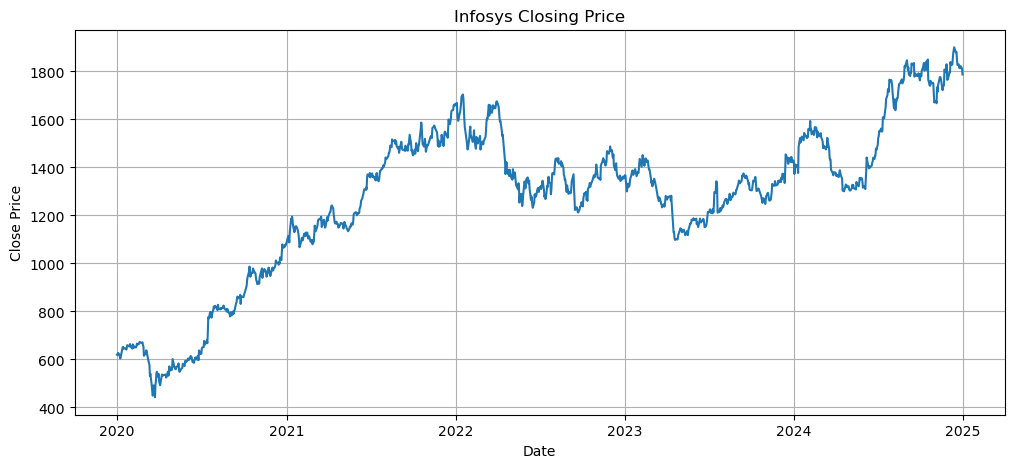

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(dataset["Close"])
plt.title("Infosys Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()

plt.show()

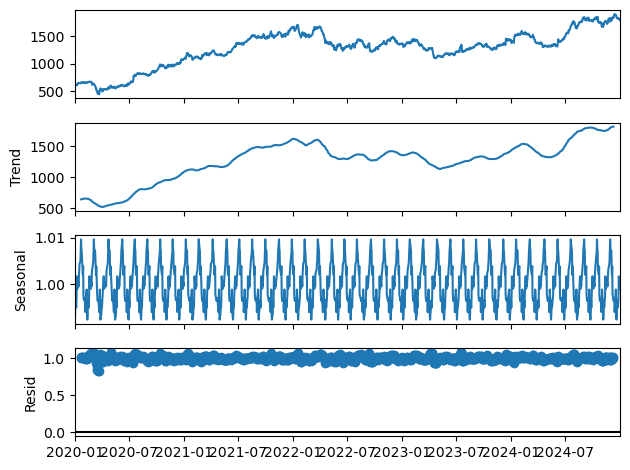

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    dataset["Close"],
    model="multiplicative",
    period=30
)

result.plot()

plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):

    result = adfuller(series)

    labels = ["ADF Statistic", "p-value", "Lags Used", "Observations"]

    for value,label in zip(result[:4],labels):
        print(label,":",value)

    if result[1] <= 0.05:
        print("\nStationary")
    else:
        print("\nNot Stationary")

adf_test(dataset["Close"])

ADF Statistic : -1.4865362724881737
p-value : 0.5401608279663919
Lags Used : 1
Observations : 1236

Not Stationary


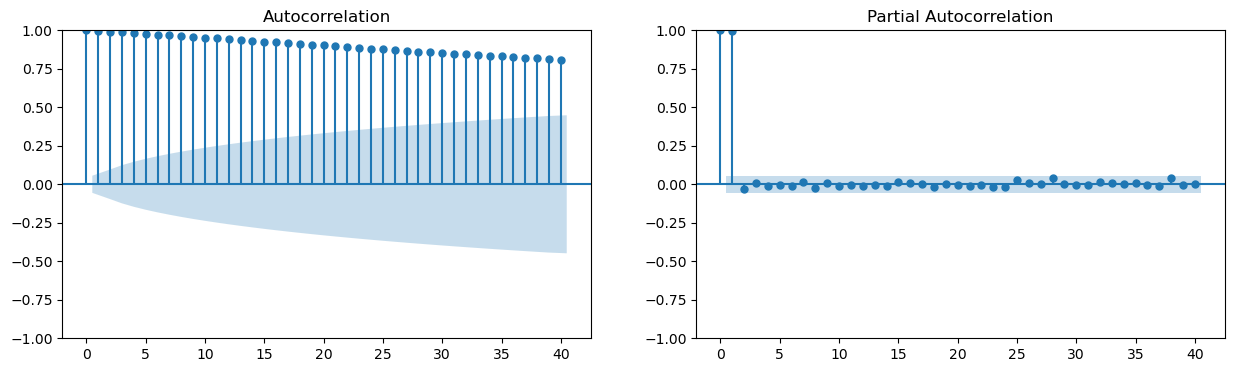

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2,figsize=(15,4))

plot_acf(dataset["Close"], lags=40, ax=ax[0])
plot_pacf(dataset["Close"], lags=40, ax=ax[1])

plt.show()

In [30]:
dataset["Difference"] = dataset["Close"].diff()
dataset.head()

Price,Open,High,Low,Close,Volume,Difference
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,
Date,,,,,,
2020-01-01,618.184342,622.389677,616.123717,619.740295,2112415,NaN
2020-01-02,621.464560,623.062557,614.736023,617.932068,5658200,-1.808228
2020-01-03,617.259204,629.118230,617.259204,627.436096,7882938,9.504028
2020-01-06,627.520099,633.996326,619.445876,621.422363,6519403,-6.013733
2020-01-07,620.707464,624.576352,609.857679,612.212708,7899363,-9.209656


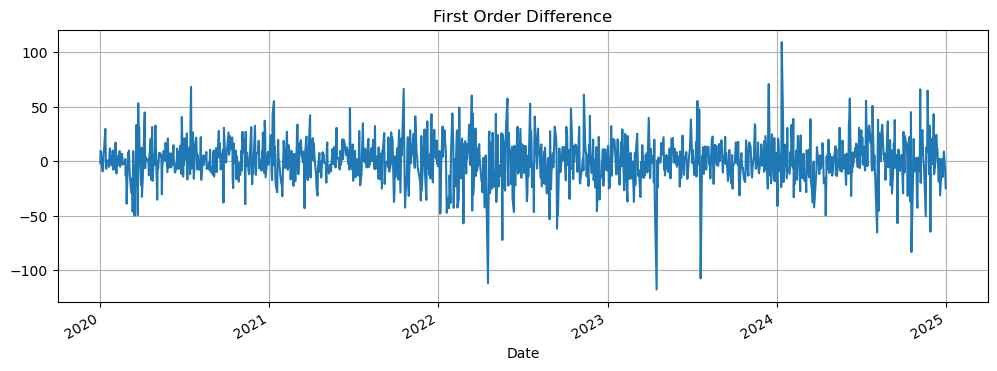

In [31]:
dataset["Difference"].dropna().plot(figsize=(12,4))
plt.title("First Order Difference")
plt.grid()
plt.show()

In [32]:
adf_test(dataset["Difference"].dropna())

ADF Statistic : -33.563826156320964
p-value : 0.0
Lags Used : 0
Observations : 1236

Stationary


In [33]:
dataset.to_csv("Infosys_Stationary.csv")